# Laboratorio 4 — Tarea de Agrupación: VuelaAlpes

**Curso:** ISIS2611  
**Metodología:** CRISP-ML  

---

## Punto 1 — Exploración de los datos y propuesta de limpieza y preparación (15%)

En esta sección se realiza una exploración exhaustiva del conjunto de datos de VuelaAlpes con el objetivo de identificar problemas de calidad (valores faltantes, outliers, distribuciones, etc.) y proponer las transformaciones necesarias para preparar los datos para los algoritmos de agrupación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga de datos

In [2]:
df = pd.read_csv('Datos_VuelaAlpes.csv')
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 10000 filas × 23 columnas


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0


---
## 2. Descripción general del conjunto de datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  str    
 2   Customer Type                      10000 non-null  str    
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  str    
 5   Class                              10000 non-null  str    
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int64  
 12  On

**Observaciones iniciales:**
- El dataset contiene **10 000 registros** y **23 variables**.
- La columna `id` es un identificador único sin valor predictivo para la agrupación.
- Hay **4 variables categóricas**: `Gender`, `Customer Type`, `Type of Travel`, `Class`.
- Las variables de servicio (`Inflight wifi service`, `Food and drink`, etc.) están en escala **0–5**.
- `Arrival Delay in Minutes` es de tipo `float64`, lo que sugiere la existencia de valores faltantes.

In [4]:
# Tipos de datos por columna
tipo_resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique(),
    'Ejemplo': df.iloc[0]
})
tipo_resumen

,Tipo,Valores únicos,Ejemplo
id,int64,10000,119496
Gender,str,2,Male
Customer Type,str,2,Loyal Customer
Age,int64,74,29
Type of Travel,str,2,Business travel
Class,str,3,Business
Flight Distance,int64,2446,814
Inflight wifi service,int64,6,3
Departure/Arrival time convenient,int64,6,3
Ease of Online booking,int64,6,3


---
## 3. Análisis de valores faltantes

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, '% del total': missing_pct.round(2)})
missing_df = missing_df[missing_df['Faltantes'] > 0]
print('Columnas con valores faltantes:')
print(missing_df)

Columnas con valores faltantes:
                          Faltantes  % del total
Arrival Delay in Minutes         25         0.25


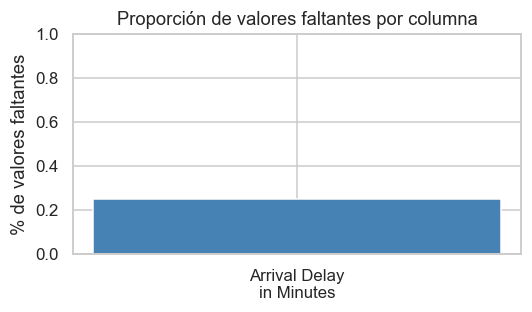

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Arrival Delay\nin Minutes'], [missing_df.loc['Arrival Delay in Minutes', '% del total']],
       color='steelblue', width=0.4)
ax.set_ylabel('% de valores faltantes')
ax.set_title('Proporción de valores faltantes por columna')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Conclusión:** Solo la columna `Arrival Delay in Minutes` presenta valores faltantes (0.25% del total). El porcentaje es muy bajo y no compromete la representatividad del dataset.

---
## 4. Estadísticas descriptivas

In [7]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,10000.0,64983.06,37610.21,1.0,32452.0,64815.5,97470.0,129879.0
Age,10000.0,39.40,15.07,7.0,27.0,40.0,51.0,80.0
Flight Distance,10000.0,1196.04,1000.59,31.0,416.0,846.0,1744.0,4963.0
Inflight wifi service,10000.0,2.73,1.33,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,10000.0,3.07,1.52,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,10000.0,2.76,1.39,0.0,2.0,3.0,4.0,5.0
Gate location,10000.0,3.00,1.28,1.0,2.0,3.0,4.0,5.0
Food and drink,10000.0,3.22,1.32,0.0,2.0,3.0,4.0,5.0
Online boarding,10000.0,3.23,1.35,0.0,2.0,3.0,4.0,5.0
Seat comfort,10000.0,3.43,1.31,1.0,2.0,4.0,4.0,5.0


**Observaciones clave:**
- `Age`: rango 7–85 años, media ≈ 39 años.
- `Flight Distance`: rango 50–4 983 km, distribución potencialmente sesgada a la derecha.
- Las variables de servicio (escala 0–5) muestran medias alrededor de 3–3.5; valor **0** puede indicar "no aplica" o falta de evaluación.
- `Departure Delay` y `Arrival Delay`: valores máximos muy altos (>1 500 min), lo que indica outliers extremos.

---
## 5. Distribución de variables categóricas

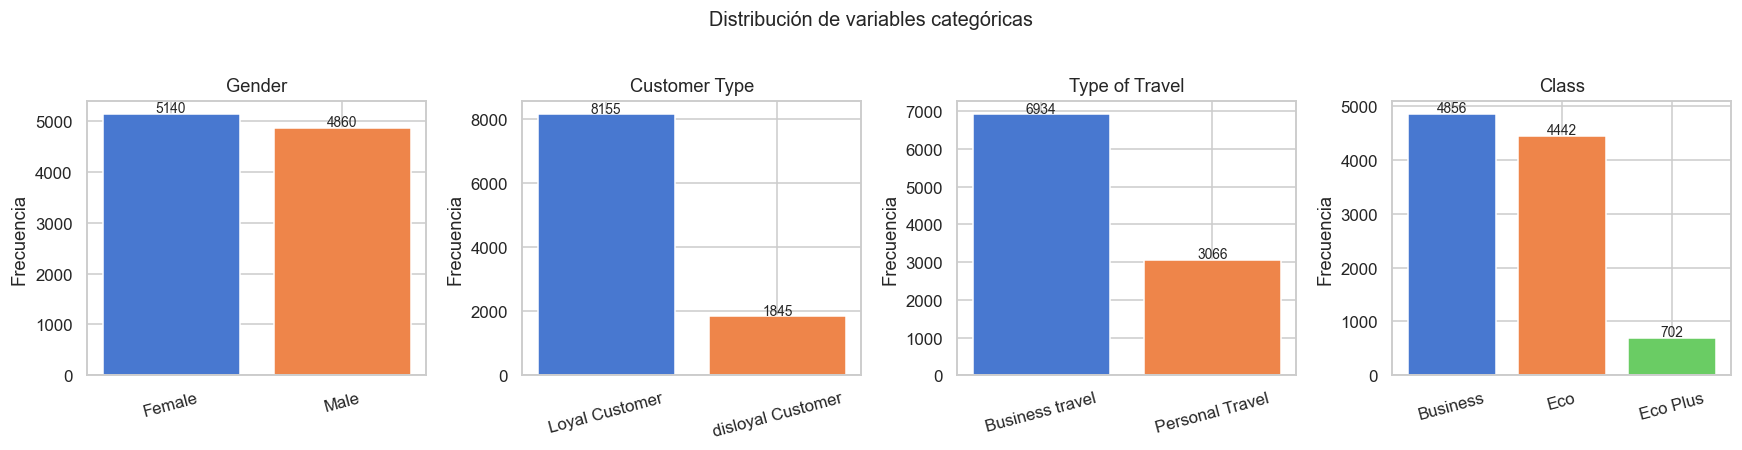

In [8]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('muted'))
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, f'{v}', ha='center', fontsize=9)
plt.suptitle('Distribución de variables categóricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observaciones:**
- `Gender`: distribución bastante equilibrada (≈50/50).
- `Customer Type`: predominan los clientes leales (~81%).
- `Type of Travel`: el viaje de negocios es mayoritario (~69%).
- `Class`: hay presencia de tres clases; "Eco Plus" es la menos frecuente.

---
## 6. Distribución de variables numéricas continuas

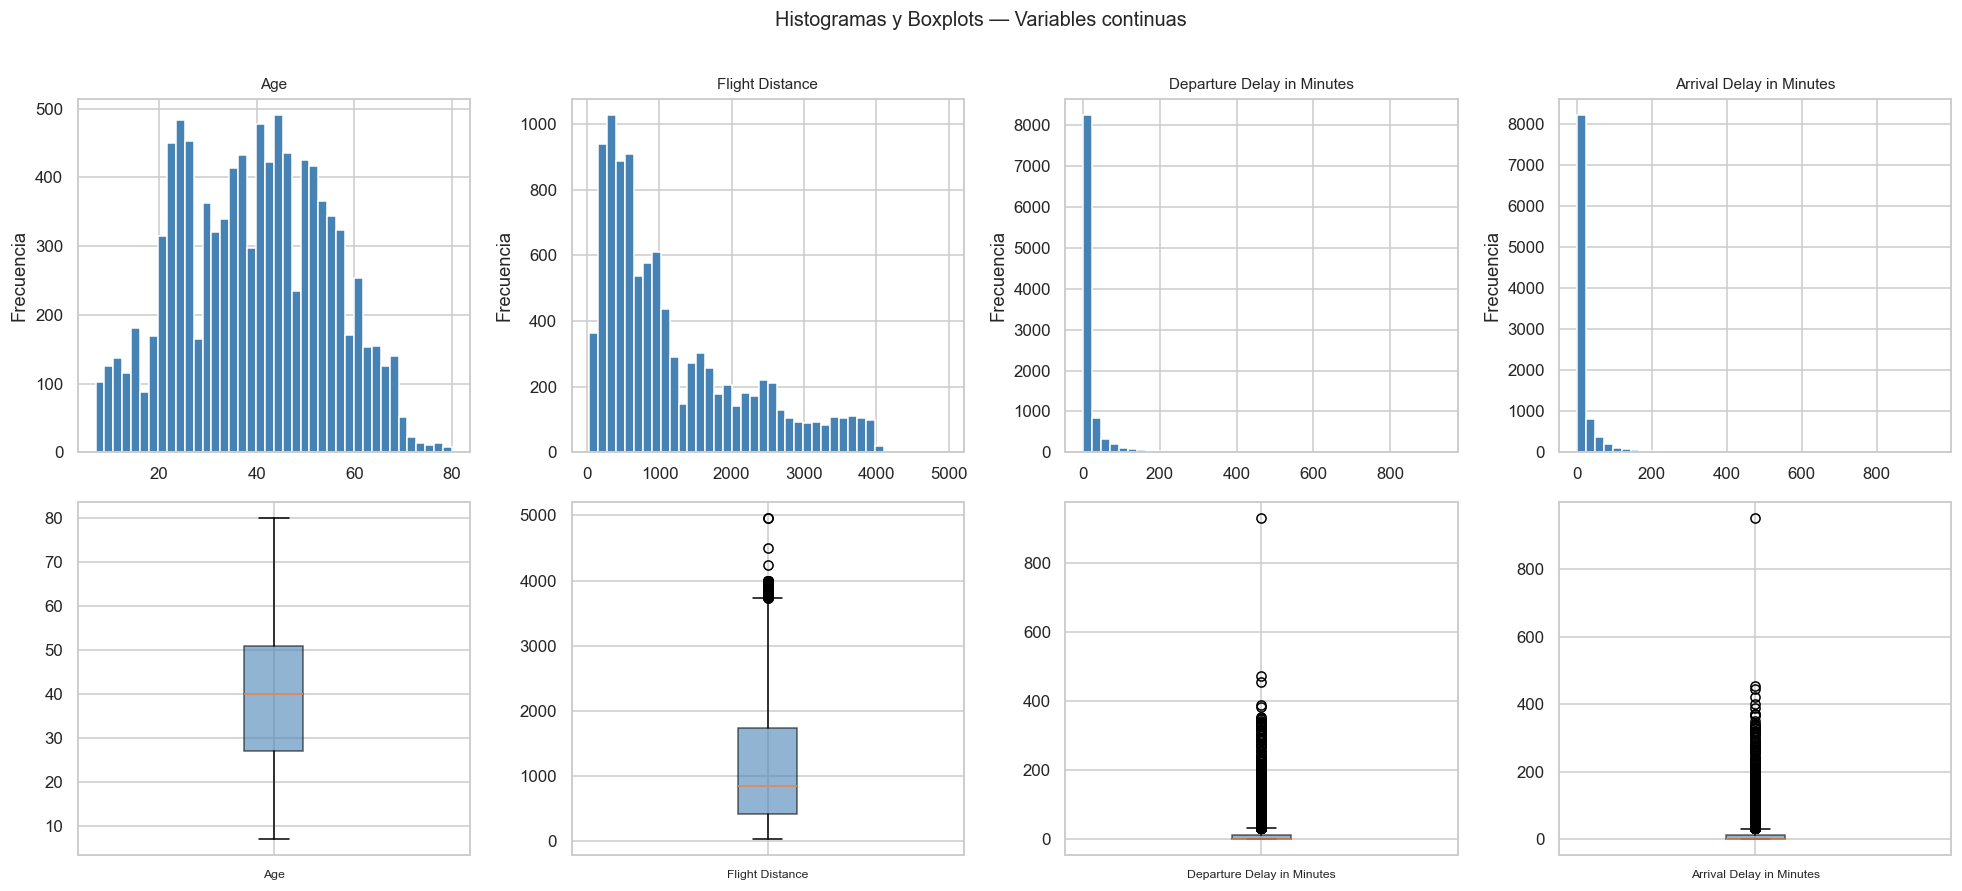

In [9]:
cont_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cont_cols):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]
    data = df[col].dropna()
    ax_hist.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax_hist.set_title(col, fontsize=10)
    ax_hist.set_ylabel('Frecuencia')
    ax_box.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax_box.set_xticklabels([col], fontsize=8)
plt.suptitle('Histogramas y Boxplots — Variables continuas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- `Age`: distribución aproximadamente normal, sin outliers extremos.
- `Flight Distance`: sesgo positivo marcado; la mayoría de vuelos son cortos/medios.
- `Departure Delay` y `Arrival Delay`: fuertemente sesgados a la derecha con outliers muy extremos (retrasos > 500 min). La gran mayoría de vuelos tienen retrasos de 0–100 min.

---
## 7. Distribución de variables de servicio (escala 0–5)

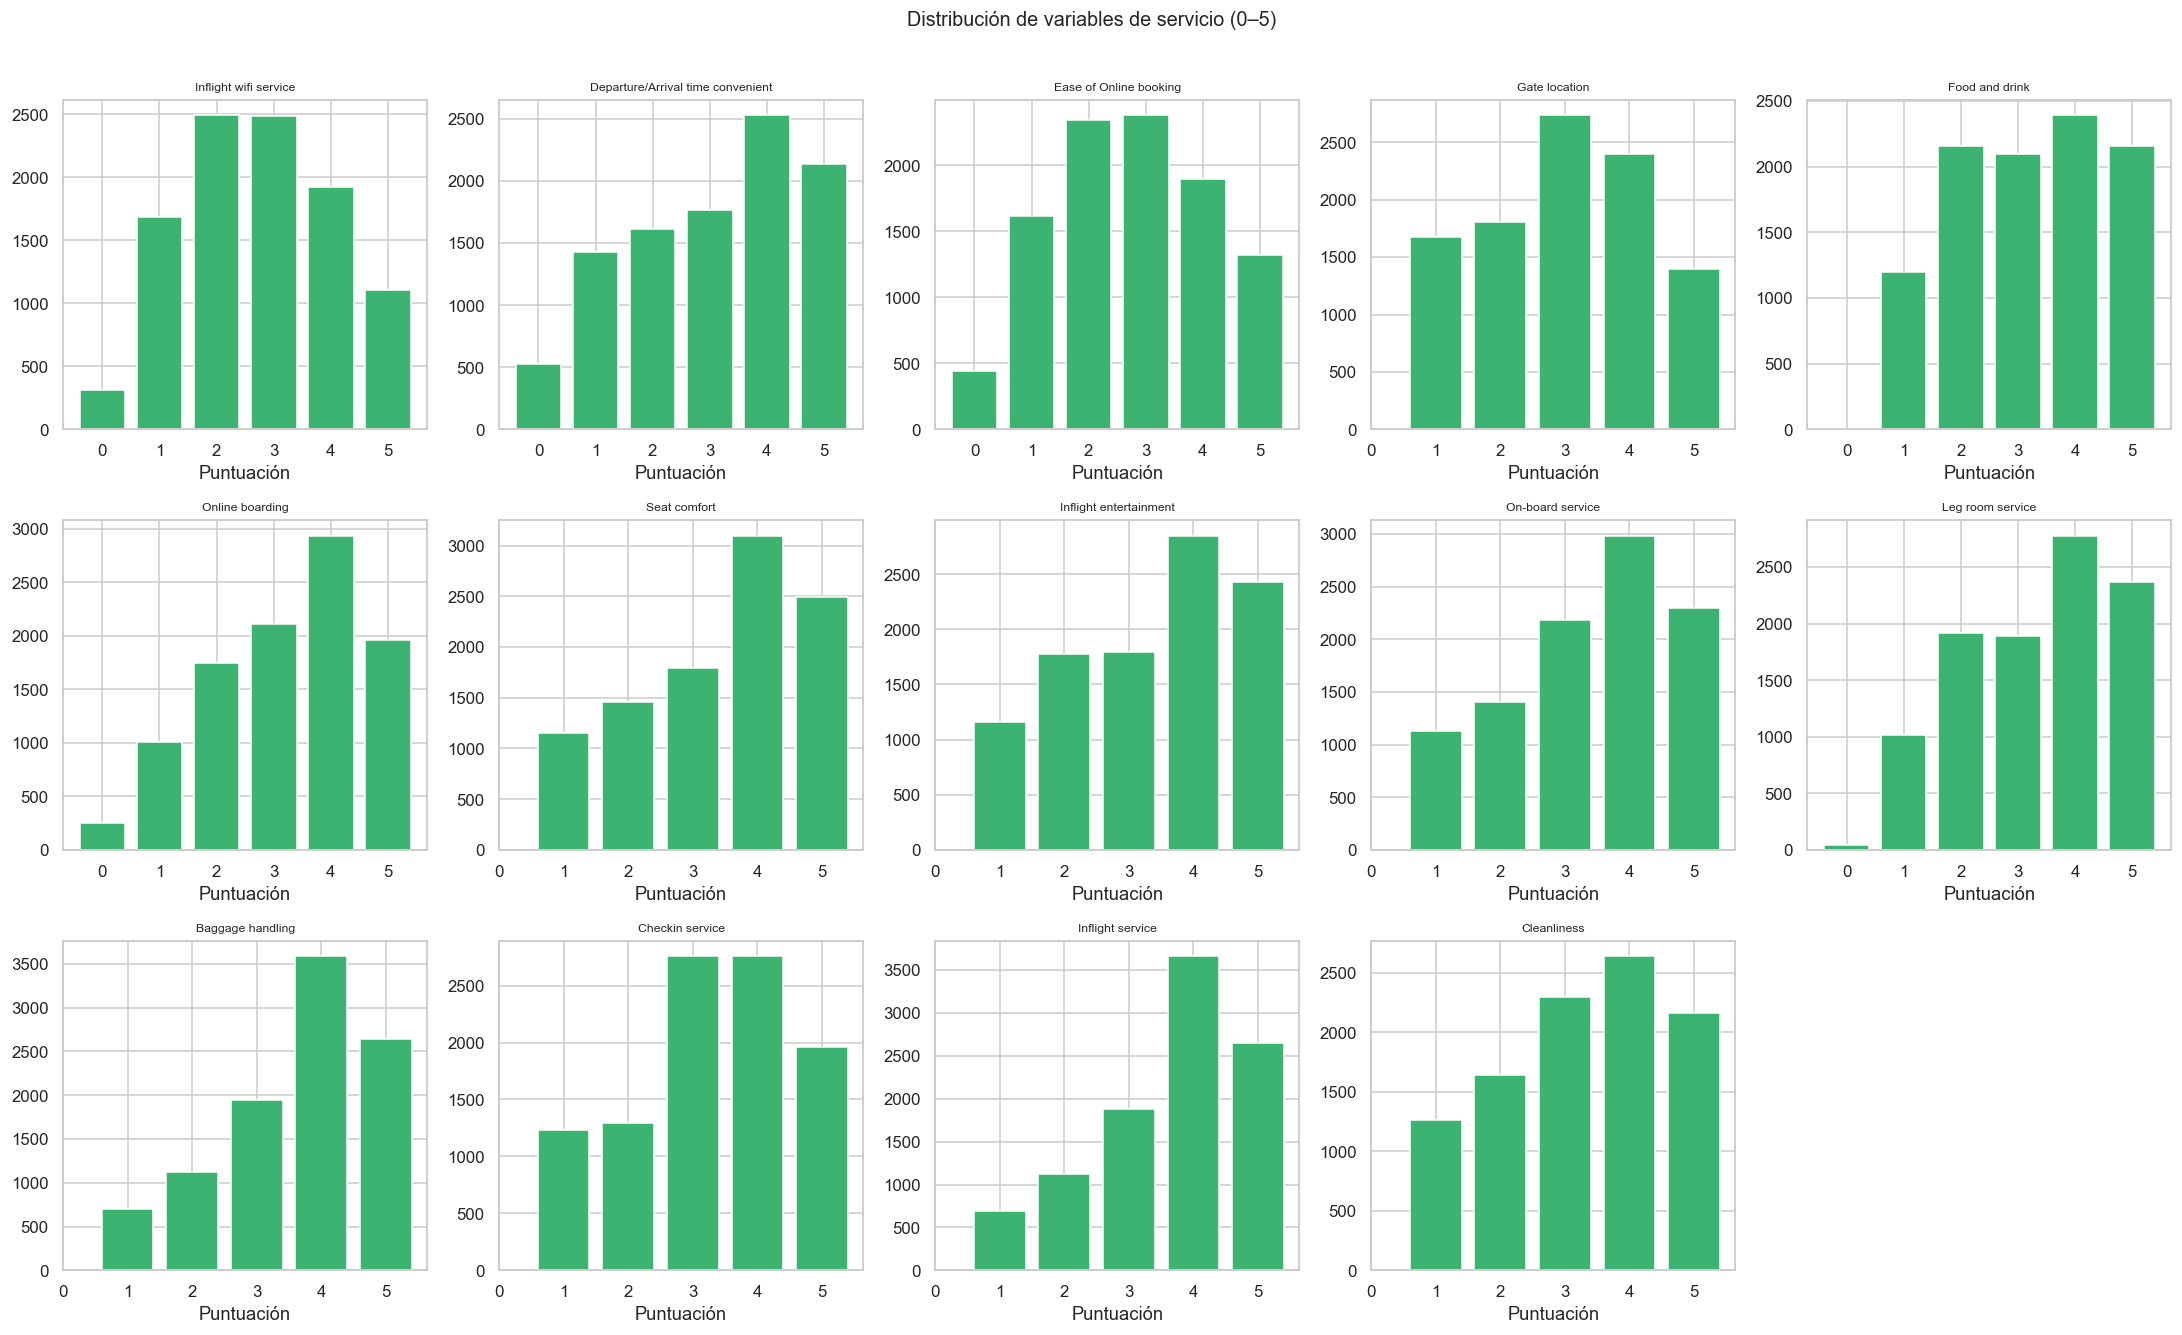

In [10]:
service_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(service_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color='mediumseagreen', edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('Puntuación')
    axes[i].set_xticks([0, 1, 2, 3, 4, 5])

# Ocultar los ejes sobrantes
for j in range(len(service_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables de servicio (0–5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Porcentaje de valor '0' en cada variable de servicio (posible 'no evaluado')
zero_pct = {col: (df[col] == 0).mean() * 100 for col in service_cols}
zero_df = pd.DataFrame.from_dict(zero_pct, orient='index', columns=['% con valor 0'])
zero_df.sort_values('% con valor 0', ascending=False).round(2)

,% con valor 0
Departure/Arrival time convenient,5.29
Ease of Online booking,4.46
Inflight wifi service,3.10
Online boarding,2.51
Leg room service,0.40
Food and drink,0.04
Gate location,0.00
Seat comfort,0.00
Inflight entertainment,0.00
On-board service,0.00


**Observaciones:**
- Varias variables de servicio tienen una proporción notable de valor `0`, especialmente `Departure/Arrival time convenient` y `Ease of Online booking`. En el diccionario de datos el valor `0` representa "no aplica", no una puntuación baja.
- La distribución de puntuaciones tiende a concentrarse en valores 3–4, con pocos extremos (1 o 5).

---
## 8. Análisis de correlaciones

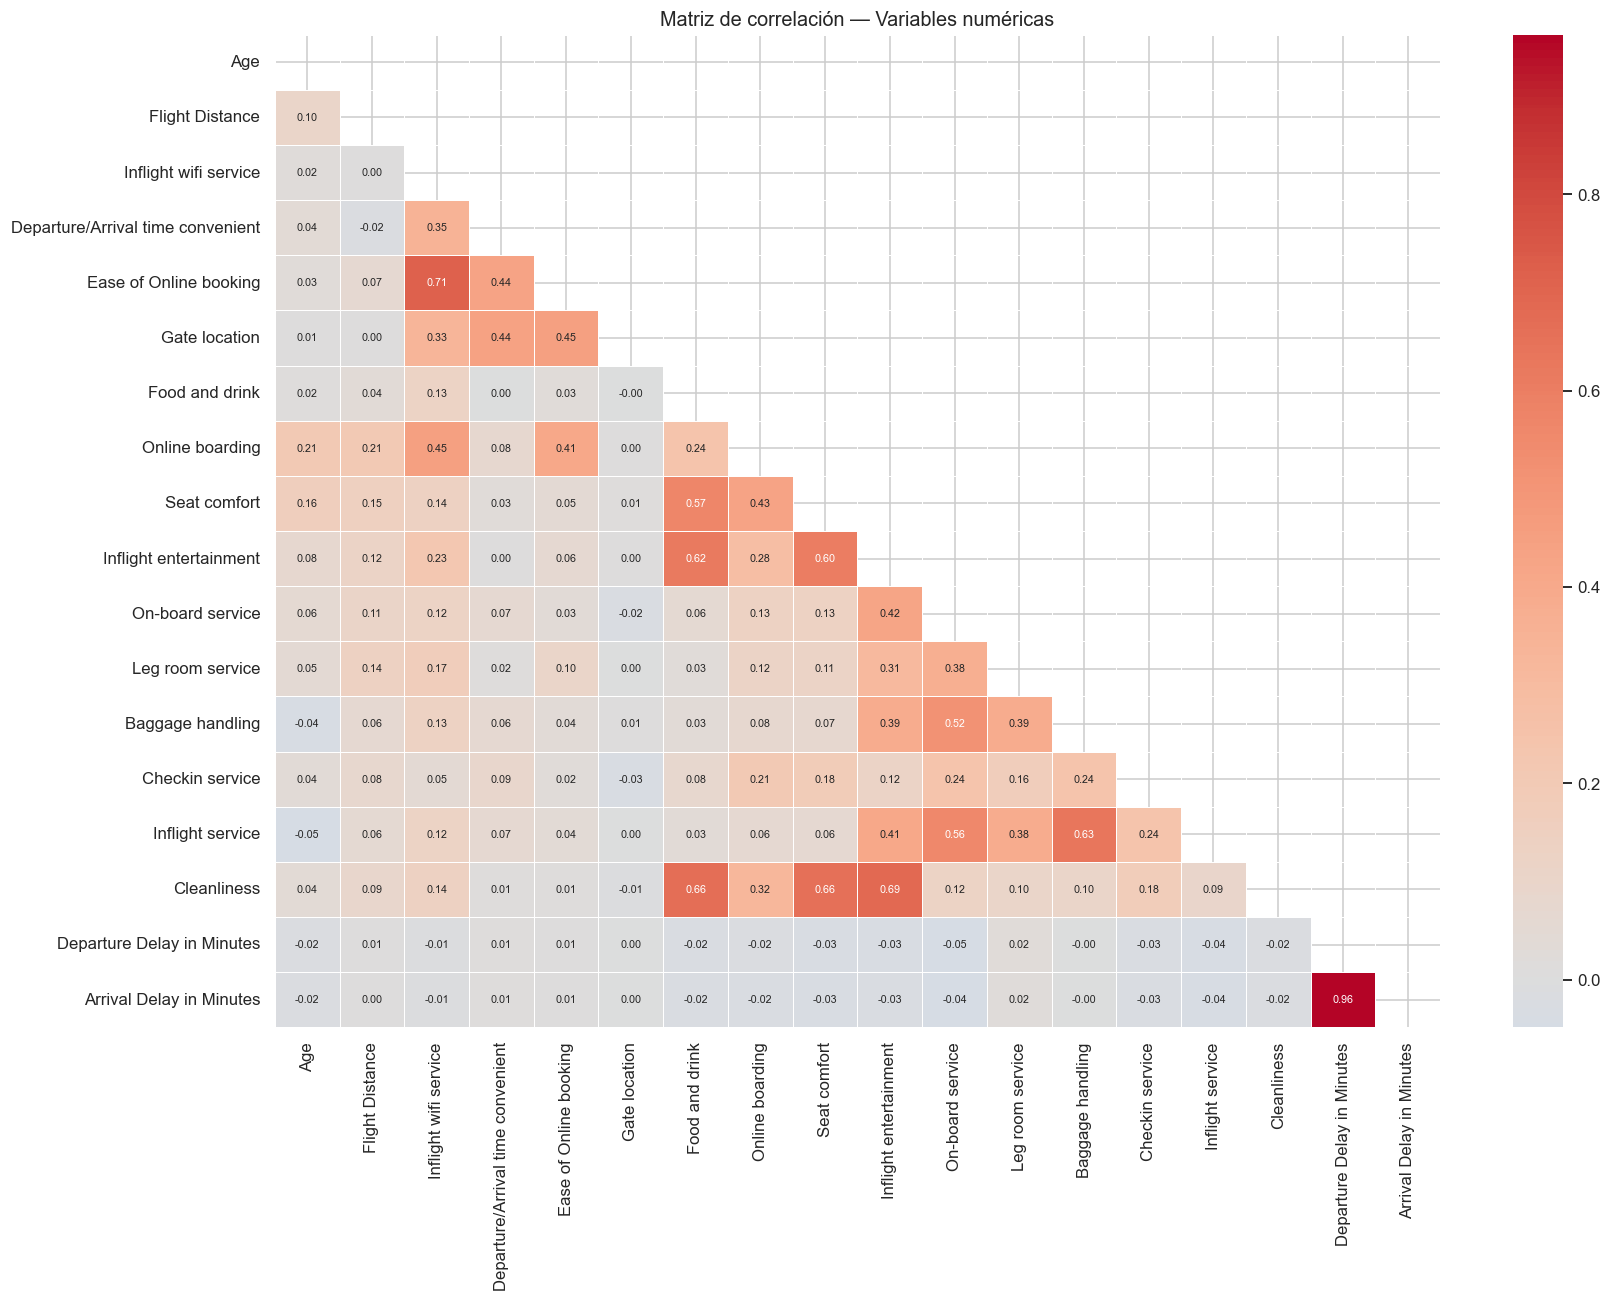

In [12]:
num_cols = [c for c in df.columns if c not in ['id'] and df[c].dtype in ['int64', 'float64']]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Matriz de correlación — Variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

**Observaciones:**
- `Departure Delay in Minutes` y `Arrival Delay in Minutes` presentan una **correlación muy alta** (> 0.95), lo que indica redundancia. Solo se conservará una de ellas.
- Las variables de servicio presentan correlaciones moderadas entre sí (0.3–0.6), lo que sugiere cierta estructura latente de satisfacción.
- `Age` y `Flight Distance` tienen baja correlación con las demás variables.

---
## 9. Detección de outliers — IQR y Z-score

In [13]:
outlier_summary = []
for col in ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    z = np.abs(stats.zscore(data))
    n_z = (z > 3).sum()
    outlier_summary.append({
        'Variable': col,
        'Outliers IQR': n_iqr,
        '% IQR': round(n_iqr / len(df) * 100, 2),
        'Outliers Z>3': n_z,
        '% Z>3': round(n_z / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,Variable,Outliers IQR,% IQR,Outliers Z>3,% Z>3
0,Age,0,0.00,0,0.00
1,Flight Distance,223,2.23,4,0.04
2,Departure Delay in Minutes,1337,13.37,231,2.31
3,Arrival Delay in Minutes,1359,13.59,226,2.26


**Observaciones:**
- `Departure Delay` y `Arrival Delay` concentran la mayoría de outliers: valores muy altos que representan situaciones atípicas de retraso extremo.
- `Flight Distance` también tiene outliers al lado alto (vuelos intercontinentales muy largos).
- `Age` no presenta outliers relevantes en cuanto a número.

---
## 10. Propuesta de limpieza y preparación de datos

Con base en los hallazgos de la exploración, se propone el siguiente proceso de limpieza y preparación. Las decisiones se justifican con relación a los algoritmos de agrupación que se aplicarán (K-Means, DBSCAN y Agglomerative Clustering).

### 10.1 Decisiones de preparación

| # | Decisión | Justificación |
|---|----------|---------------|
| 1 | **Eliminar columna `id`** | Identificador único sin información para la agrupación. |
| 2 | **Imputar `Arrival Delay in Minutes` con la mediana** | Solo el 0.25% de los registros tienen valor faltante; la mediana es robusta ante la distribución sesgada de los retrasos. |
| 3 | **Eliminar `Departure Delay in Minutes`** | Correlación > 0.95 con `Arrival Delay in Minutes`; conservar solo una evita multicolinealidad. |
| 4 | **Aplicar winsorización (percentil 1–99) a `Flight Distance` y `Arrival Delay`** | Reduce el impacto de outliers extremos sin eliminar registros. K-Means y Agglomerative son muy sensibles a outliers dado que trabajan con distancias euclidianas. |
| 5 | **Codificar variables categóricas con One-Hot Encoding** | Gender, Customer Type, Type of Travel y Class son variables nominales; OHE evita imponer orden artificial. Se omite la primera columna para evitar multicolinealidad (drop='first'). |
| 6 | **Escalar todas las variables numéricas con StandardScaler** | K-Means, DBSCAN y Agglomerative Clustering son sensibles a la magnitud de las variables. El escalado garantiza que ninguna variable domine la función de distancia. |

### 10.2 Implementación de la limpieza y preparación

In [14]:
from sklearn.preprocessing import StandardScaler

# ----- Paso 1: copia de trabajo -----
df_clean = df.copy()

# ----- Paso 2: Eliminar columna 'id' -----
df_clean.drop(columns=['id'], inplace=True)

# ----- Paso 3: Imputar valores faltantes de Arrival Delay con la mediana -----
mediana_arrival = df_clean['Arrival Delay in Minutes'].median()
df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)
print(f'Mediana usada para imputación: {mediana_arrival} min')
print(f'Valores faltantes tras imputación: {df_clean["Arrival Delay in Minutes"].isnull().sum()}')

Mediana usada para imputación: 0.0 min
Valores faltantes tras imputación: 25


C:\Users\scast\AppData\Local\Temp\ipykernel_13512\745674499.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)


In [15]:
# ----- Paso 4: Eliminar 'Departure Delay in Minutes' (alta correlación con Arrival Delay) -----
df_clean.drop(columns=['Departure Delay in Minutes'], inplace=True)
print('Columnas restantes:', df_clean.columns.tolist())

Columnas restantes: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']


In [16]:
# ----- Paso 5: Winsorización (percentiles 1–99) para Flight Distance y Arrival Delay -----
def winsorizacion(series, lower_pct=0.01, upper_pct=0.99):
    lower = series.quantile(lower_pct)
    upper = series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

for col in ['Flight Distance', 'Arrival Delay in Minutes']:
    antes_max = df_clean[col].max()
    df_clean[col] = winsorizacion(df_clean[col])
    despues_max = df_clean[col].max()
    print(f'{col}: máximo antes={antes_max:.1f} → después={despues_max:.1f}')

Flight Distance: máximo antes=4963.0 → después=3874.0
Arrival Delay in Minutes: máximo antes=952.0 → después=179.0


In [17]:
# ----- Paso 6: One-Hot Encoding de variables categóricas -----
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)
print('Dimensiones después de OHE:', df_encoded.shape)
print('Nuevas columnas:', [c for c in df_encoded.columns if c not in df_clean.columns])

Dimensiones después de OHE: (10000, 22)
Nuevas columnas: ['Gender_Male', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']


In [18]:
# ----- Paso 7: Escalado con StandardScaler -----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print('Media por columna (debe ser ≈ 0):')
print(df_scaled.mean().round(4))
print('\nDesv. estándar por columna (debe ser ≈ 1):')
print(df_scaled.std().round(4))

Media por columna (debe ser ≈ 0):
Age                                  0.0
Flight Distance                     -0.0
Inflight wifi service               -0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                       -0.0
Food and drink                       0.0
Online boarding                     -0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                    -0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                         -0.0
Arrival Delay in Minutes            -0.0
Gender_Male                          0.0
Customer Type_disloyal Customer      0.0
Type of Travel_Personal Travel       0.0
Class_Eco                            0.0
Class_Eco Plus                      -0.0
dtype: float64

Desv. estándar por columna (debe ser ≈ 1):
Age  

In [19]:
# Resumen final del dataset preparado
print('=== Dataset final preparado para modelamiento ===')
print(f'  Filas: {df_scaled.shape[0]}')
print(f'  Columnas: {df_scaled.shape[1]}')
print(f'  Valores faltantes: {df_scaled.isnull().sum().sum()}')
df_scaled.head()

=== Dataset final preparado para modelamiento ===
  Filas: 10000
  Columnas: 22
  Valores faltantes: 25


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,-0.690324,-0.382148,0.199676,-0.048670,0.170275,-0.002182,0.592561,0.566942,0.432515,0.480124,...,1.151990,0.560414,0.301177,0.548283,-0.269045,1.028403,-0.475649,-0.664958,-0.893985,-0.274773
1,0.968423,1.721833,0.952319,0.609036,0.887523,0.777169,0.592561,0.566942,0.432515,0.480124,...,0.307546,0.560414,0.301177,0.548283,-0.173169,1.028403,-0.475649,-0.664958,-0.893985,-0.274773
2,0.835724,-0.920423,0.952319,1.266742,1.604772,1.556521,0.592561,0.566942,0.432515,0.480124,...,0.307546,-0.230796,0.301177,0.548283,0.881464,1.028403,-0.475649,-0.664958,1.118588,-0.274773
3,-1.486523,0.550059,0.199676,-2.021789,0.170275,-1.560885,0.592561,-0.173675,-1.849082,0.480124,...,1.151990,0.560414,1.146467,0.548283,0.785588,-0.972381,-0.475649,1.503855,1.118588,-0.274773
4,-0.623974,0.245337,0.199676,0.609036,0.170275,-0.781534,-0.162486,-0.173675,-0.328017,-0.272303,...,0.307546,1.351624,0.301177,-0.214492,-0.460796,-0.972381,-0.475649,1.503855,1.118588,-0.274773


---
## 11. Resumen de hallazgos y decisiones

| Hallazgo | Decisión tomada |
|----------|----------------|
| Columna `id` es un identificador irrelevante | Eliminada |
| 25 valores faltantes en `Arrival Delay` (0.25%) | Imputados con la mediana |
| `Departure Delay` y `Arrival Delay` con correlación > 0.95 | Se conserva solo `Arrival Delay` |
| Outliers extremos en `Flight Distance` y `Arrival Delay` | Winsorización al percentil 99 |
| 4 variables categóricas nominales | One-Hot Encoding con drop_first=True |
| Variables en escalas muy diferentes (km, minutos, 0–5) | Estandarización con StandardScaler |

El dataset resultante cuenta con **10 000 filas** y **19 variables** todas numéricas, sin valores faltantes y correctamente escaladas, listo para aplicar los algoritmos de agrupación en el Punto 2.

---
## Punto 2 -- Descripcion y aplicacion de tres algoritmos de agrupacion (30%)

Se aplican tres algoritmos de agrupacion: **K-Means**, **DBSCAN** y **Agglomerative Clustering**.
Para cada uno se realiza busqueda de hiperparametros y se construye un **Pipeline** de sklearn
que integra preprocesamiento (winsorizacion, estandarizacion, OHE) y modelo en un flujo reproducible.

In [20]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
import warnings
warnings.filterwarnings('ignore')
print('Librerias de modelamiento cargadas.')

Librerias de modelamiento cargadas.


In [21]:
df_model = pd.read_csv("Datos_VuelaAlpes.csv")
df_model["Arrival Delay in Minutes"] = df_model["Arrival Delay in Minutes"].fillna(
    df_model["Arrival Delay in Minutes"].median())
df_model.drop(columns=["id", "Departure Delay in Minutes"], inplace=True)

num_cols_m = [c for c in df_model.columns
              if c not in ["Gender", "Customer Type", "Type of Travel", "Class"]]
cat_cols_m  = ["Gender", "Customer Type", "Type of Travel", "Class"]

print(f"Filas x columnas: {df_model.shape}")
print(f"Numericas ({len(num_cols_m)}): {num_cols_m}")
print(f"Categoricas ({len(cat_cols_m)}): {cat_cols_m}")

Filas x columnas: (10000, 21)
Numericas (17): ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']
Categoricas (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [22]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
    def fit(self, X, y=None):
        self.lo_ = np.nanpercentile(X, self.lower * 100, axis=0)
        self.hi_ = np.nanpercentile(X, self.upper * 100, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

def make_preprocessor():
    num_pipe = Pipeline([('winsor', Winsorizer()), ('scaler', StandardScaler())])
    return ColumnTransformer([
        ('num', num_pipe, num_cols_m),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_m)
    ], remainder='drop')

preproc_shared = make_preprocessor()
X_prep = preproc_shared.fit_transform(df_model)
print(f'Datos preprocesados: {X_prep.shape}')

pca_viz = PCA(n_components=2, random_state=42)
X_pca   = pca_viz.fit_transform(X_prep)
print(f'Varianza explicada PC1+PC2: {pca_viz.explained_variance_ratio_.sum()*100:.1f}%')

Datos preprocesados: (10000, 22)
Varianza explicada PC1+PC2: 34.9%


---
### Algoritmo 1: K-Means

**Descripcion:** K-Means es un algoritmo de agrupacion basado en **centroides**. Minimiza la
*inercia* (suma de distancias cuadraticas de cada punto al centroide de su cluster).

**Funcionamiento:**
1. Inicializa *k* centroides con `k-means++` (reduce varianza de la solucion).
2. Asigna cada punto al centroide mas cercano (distancia euclidea).
3. Recalcula cada centroide como la media de sus puntos asignados.
4. Repite 2-3 hasta convergencia.

**Hiperparametros:** `n_clusters` (k) -- optimizado con el metodo del codo y silueta;
`init='k-means++'`; `n_init=10`.

**Restricciones:** asume clusters convexos y de tamano similar; requiere *k* a priori;
sensible a outliers (mitigado con winsorizacion).
nan_count = np.isnan(X_prep).sum()
print(f"NaN en X_prep: {nan_count}")
assert nan_count == 0, f"X_prep tiene {nan_count} NaN -- revisar preprocesamiento"

In [23]:
inertias      = []
sil_scores_km = []
k_range       = range(2, 11)

for k in k_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbs = km.fit_predict(X_prep)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_prep, lbs, random_state=42)
    sil_scores_km.append(sil)
    print(f'k={k:2d} | inercia={km.inertia_:>12.0f} | silhouette={sil:.4f}')

k= 2 | inercia=      151606 | silhouette=0.1477


k= 3 | inercia=      139669 | silhouette=0.1151


k= 4 | inercia=      129926 | silhouette=0.1155


k= 5 | inercia=      124003 | silhouette=0.1139


k= 6 | inercia=      118835 | silhouette=0.1193


k= 7 | inercia=      114979 | silhouette=0.1103


k= 8 | inercia=      111241 | silhouette=0.1106


k= 9 | inercia=      108614 | silhouette=0.1104


k=10 | inercia=      106235 | silhouette=0.1033


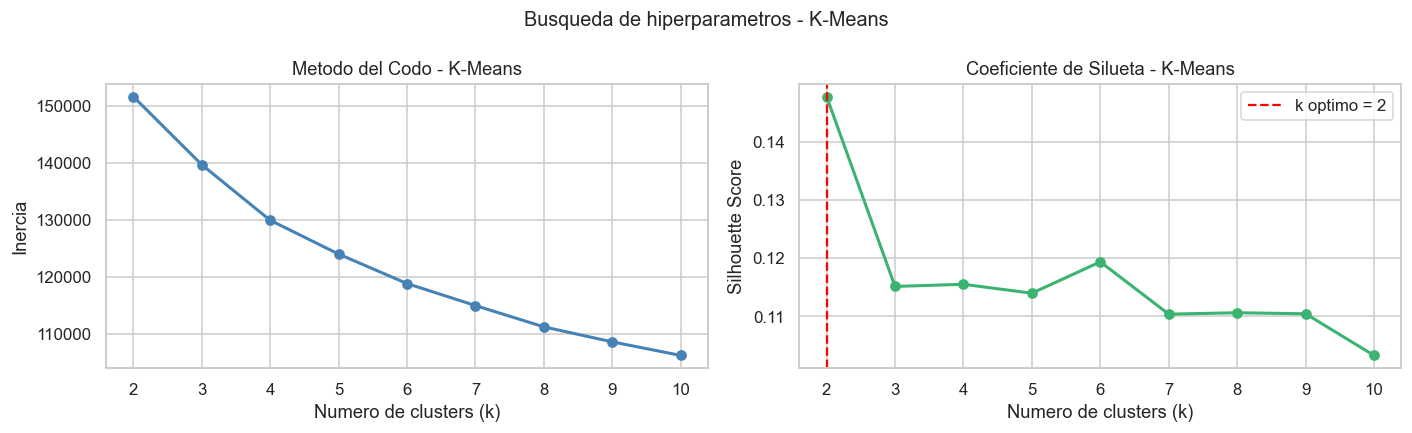

k optimo: 2  |  silhouette = 0.1477


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Numero de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Metodo del Codo - K-Means')
ax1.set_xticks(list(k_range))

ax2.plot(list(k_range), sil_scores_km, 'o-', color='mediumseagreen', linewidth=2)
ax2.set_xlabel('Numero de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Coeficiente de Silueta - K-Means')
ax2.set_xticks(list(k_range))

k_opt_km = list(k_range)[int(np.argmax(sil_scores_km))]
ax2.axvline(k_opt_km, color='red', linestyle='--', label=f'k optimo = {k_opt_km}')
ax2.legend()

plt.suptitle('Busqueda de hiperparametros - K-Means', fontsize=13)
plt.tight_layout()
plt.show()
print(f'k optimo: {k_opt_km}  |  silhouette = {max(sil_scores_km):.4f}')

In [25]:
pipeline_kmeans = Pipeline([
    ('prep',   make_preprocessor()),
    ('kmeans', KMeans(n_clusters=k_opt_km, init='k-means++', n_init=10, random_state=42))
])

labels_km = pipeline_kmeans.fit_predict(df_model)
sil_km    = silhouette_score(X_prep, labels_km, random_state=42)

print(pipeline_kmeans)
print(f'\nSilhouette Score final (k={k_opt_km}): {sil_km:.4f}')
print('\nDistribucion de clusters:')
vals_km, cnts_km = np.unique(labels_km, return_counts=True)
for v, c in zip(vals_km, cnts_km):
    print(f'  Cluster {v}: {c:>5} pasajeros ({c/len(labels_km)*100:.1f}%)')

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
               

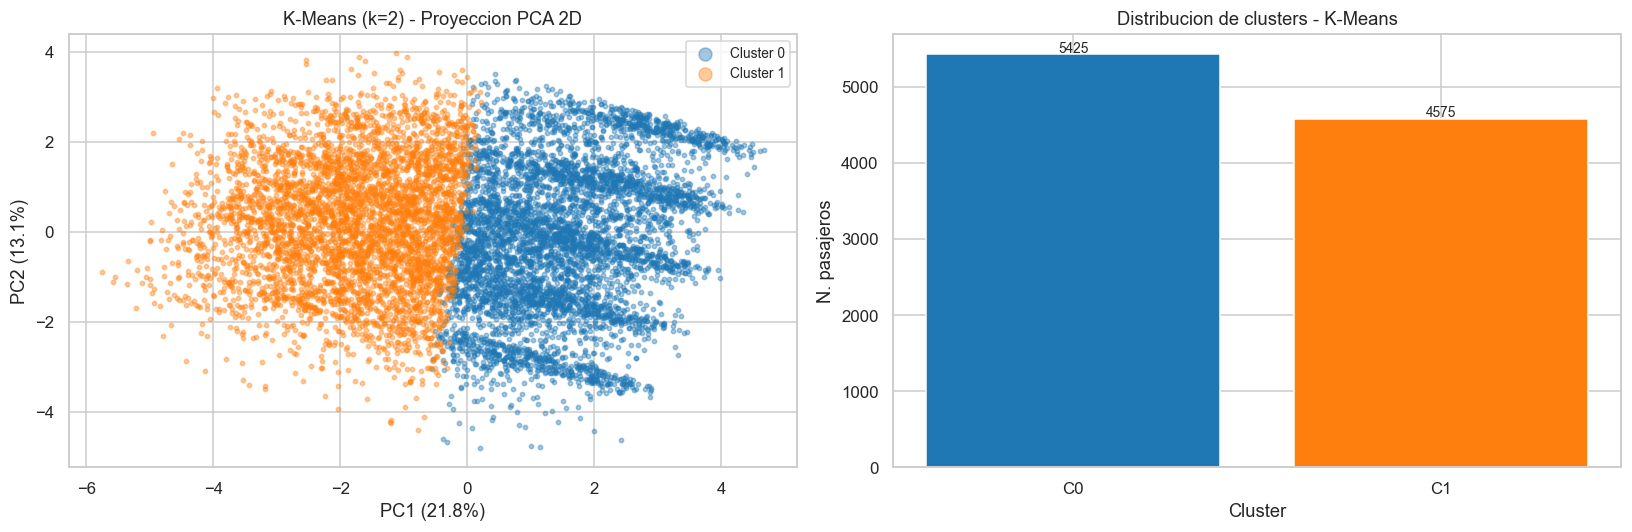

In [26]:
palette_km = sns.color_palette('tab10', k_opt_km)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i in range(k_opt_km):
    m = labels_km == i
    ax1.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.4,
                color=palette_km[i], label=f'Cluster {i}')
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'K-Means (k={k_opt_km}) - Proyeccion PCA 2D')
ax1.legend(markerscale=3, fontsize=9)

ax2.bar([f'C{v}' for v in vals_km], cnts_km, color=palette_km)
ax2.set_xlabel('Cluster'); ax2.set_ylabel('N. pasajeros')
ax2.set_title('Distribucion de clusters - K-Means')
for i, (v, c) in enumerate(zip(vals_km, cnts_km)):
    ax2.text(i, c + 30, str(c), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

---
### Algoritmo 2: DBSCAN

**Descripcion:** DBSCAN agrupa puntos segun su **densidad local**.
Define un cluster como una region densa de puntos conectados por vecindad.

**Conceptos clave:**
- **Core point:** tiene >= `min_samples` vecinos dentro del radio `eps`.
- **Border point:** en la vecindad de un core point pero no es core.
- **Noise (-1):** no pertenece a ningun cluster.

**Hiperparametros:** `eps` (radio de vecindad, estimado con grafico k-NN);
`min_samples` (densidad minima para un core point).

**Ventajas:** no requiere *k* a priori; detecta formas arbitrarias; identifica outliers.

**Restricciones:** dificil de calibrar en alta dimension; sensible a variaciones de densidad
entre clusters; sensible a la eleccion de `eps` y `min_samples`.

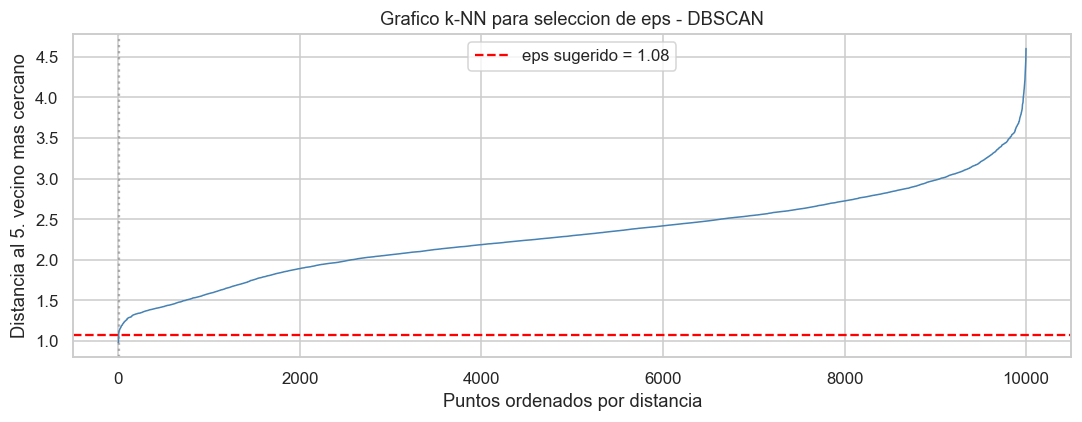

eps sugerido: 1.08


In [27]:
nbrs        = NearestNeighbors(n_neighbors=5, algorithm='auto').fit(X_prep)
knn_dist, _ = nbrs.kneighbors(X_prep)
knn_sorted  = np.sort(knn_dist[:, -1])

diffs      = np.diff(knn_sorted)
diffs2     = np.diff(diffs)
elbow_idx  = int(np.argmax(diffs2)) + 2
eps_suggest = round(float(knn_sorted[elbow_idx]), 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_sorted, color='steelblue', linewidth=1)
ax.axvline(elbow_idx, color='grey', linestyle=':', alpha=0.6)
ax.axhline(eps_suggest, color='red', linestyle='--',
           label=f'eps sugerido = {eps_suggest}')
ax.set_xlabel('Puntos ordenados por distancia')
ax.set_ylabel('Distancia al 5. vecino mas cercano')
ax.set_title('Grafico k-NN para seleccion de eps - DBSCAN')
ax.legend()
plt.tight_layout(); plt.show()
print(f'eps sugerido: {eps_suggest}')

In [28]:
eps_grid = [round(eps_suggest * f, 2) for f in [0.6, 0.8, 1.0, 1.3, 1.7]]
ms_grid  = [5, 10, 20]

dbscan_res = []
for eps in eps_grid:
    for ms in ms_grid:
        lbs     = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_prep)
        n_cls   = len(set(lbs)) - (1 if -1 in lbs else 0)
        n_noise = (lbs == -1).sum()
        valid   = lbs != -1
        if n_cls >= 2 and valid.sum() > 200:
            sil = silhouette_score(X_prep[valid], lbs[valid],
                                   sample_size=min(3000, int(valid.sum())), random_state=42)
        else:
            sil = np.nan
        dbscan_res.append({'eps': eps, 'min_samples': ms,
                           'n_clusters': n_cls, 'n_noise': n_noise,
                           'pct_noise': round(n_noise / len(lbs) * 100, 1),
                           'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan})
        tag = f'{sil:.4f}' if not np.isnan(sil) else 'N/A'
        print(f'eps={eps:.2f}, ms={ms:2d} | cls={n_cls:2d}, '
              f'ruido={n_noise:5d} ({n_noise/len(lbs)*100:4.1f}%), sil={tag}')

df_dbscan_res = pd.DataFrame(dbscan_res)
print('\n=== Tabla de resultados DBSCAN ===')
df_dbscan_res

eps=0.65, ms= 5 | cls= 0, ruido=10000 (100.0%), sil=N/A
eps=0.65, ms=10 | cls= 0, ruido=10000 (100.0%), sil=N/A


eps=0.65, ms=20 | cls= 0, ruido=10000 (100.0%), sil=N/A
eps=0.86, ms= 5 | cls= 0, ruido=10000 (100.0%), sil=N/A
eps=0.86, ms=10 | cls= 0, ruido=10000 (100.0%), sil=N/A


eps=0.86, ms=20 | cls= 0, ruido=10000 (100.0%), sil=N/A
eps=1.08, ms= 5 | cls= 4, ruido= 9980 (99.8%), sil=N/A
eps=1.08, ms=10 | cls= 0, ruido=10000 (100.0%), sil=N/A


eps=1.08, ms=20 | cls= 0, ruido=10000 (100.0%), sil=N/A
eps=1.40, ms= 5 | cls=36, ruido= 9099 (91.0%), sil=0.0059
eps=1.40, ms=10 | cls=14, ruido= 9817 (98.2%), sil=N/A


eps=1.40, ms=20 | cls= 0, ruido=10000 (100.0%), sil=N/A


eps=1.84, ms= 5 | cls=64, ruido= 7417 (74.2%), sil=-0.0969
eps=1.84, ms=10 | cls= 4, ruido= 8298 (83.0%), sil=0.1044


eps=1.84, ms=20 | cls= 1, ruido= 8568 (85.7%), sil=N/A

=== Tabla de resultados DBSCAN ===


,eps,min_samples,n_clusters,n_noise,pct_noise,silhouette
0,0.65,5,0,10000,100.0,NaN
1,0.65,10,0,10000,100.0,NaN
2,0.65,20,0,10000,100.0,NaN
3,0.86,5,0,10000,100.0,NaN
4,0.86,10,0,10000,100.0,NaN
5,0.86,20,0,10000,100.0,NaN
6,1.08,5,4,9980,99.8,NaN
7,1.08,10,0,10000,100.0,NaN
8,1.08,20,0,10000,100.0,NaN
9,1.40,5,36,9099,91.0,0.0059


In [29]:
df_valid_db = df_dbscan_res[(df_dbscan_res['pct_noise'] < 40) &
                             df_dbscan_res['silhouette'].notna()]
if df_valid_db.empty:
    df_valid_db = df_dbscan_res[df_dbscan_res['silhouette'].notna()]

best_db = df_valid_db.sort_values('silhouette', ascending=False).iloc[0]
eps_opt = best_db['eps']
ms_opt  = int(best_db['min_samples'])
print(f'Mejor configuracion: eps={eps_opt}, min_samples={ms_opt}')
print(f'  Clusters: {int(best_db["n_clusters"])}, '
      f'Ruido: {best_db["pct_noise"]}%, '
      f'Silhouette: {best_db["silhouette"]:.4f}')

pipeline_dbscan = Pipeline([
    ('prep',   make_preprocessor()),
    ('dbscan', DBSCAN(eps=eps_opt, min_samples=ms_opt))
])

labels_db  = pipeline_dbscan.fit_predict(df_model)
n_cls_db   = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
valid_db   = labels_db != -1
sil_db = silhouette_score(X_prep[valid_db], labels_db[valid_db],
                           sample_size=min(5000, int(valid_db.sum())), random_state=42) \
         if n_cls_db >= 2 else float('nan')

print(pipeline_dbscan)
print(f'\nClusters encontrados: {n_cls_db}')
print(f'Puntos de ruido:      {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)')
print(f'Silhouette Score (sin ruido): {sil_db:.4f}')

Mejor configuracion: eps=1.84, min_samples=10
  Clusters: 4, Ruido: 83.0%, Silhouette: 0.1044


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
               



Clusters encontrados: 4
Puntos de ruido:      8298 (83.0%)
Silhouette Score (sin ruido): 0.1044


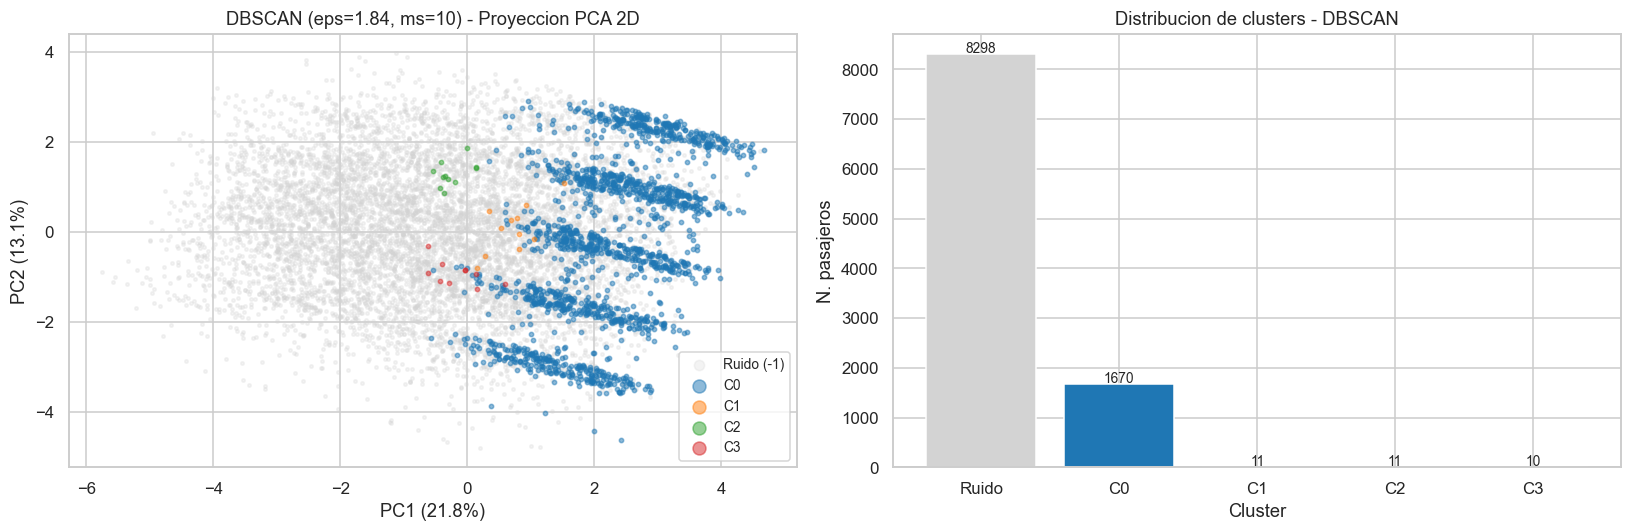

In [30]:
n_real_cls = max(labels_db) + 1
palette_db = sns.color_palette('tab10', max(n_real_cls, 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

noise_m = labels_db == -1
ax1.scatter(X_pca[noise_m, 0], X_pca[noise_m, 1],
            s=5, alpha=0.25, color='lightgrey', label='Ruido (-1)')
for i in range(n_real_cls):
    m = labels_db == i
    ax1.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.5,
                color=palette_db[i], label=f'C{i}')
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'DBSCAN (eps={eps_opt}, ms={ms_opt}) - Proyeccion PCA 2D')
ax1.legend(markerscale=3, fontsize=9)

vals_db, cnts_db = np.unique(labels_db, return_counts=True)
bar_labels = ['Ruido' if v == -1 else f'C{v}' for v in vals_db]
bar_colors = ['lightgrey'] + [palette_db[v] for v in vals_db if v >= 0]
ax2.bar(bar_labels, cnts_db, color=bar_colors[:len(bar_labels)])
ax2.set_xlabel('Cluster'); ax2.set_ylabel('N. pasajeros')
ax2.set_title('Distribucion de clusters - DBSCAN')
for i, c in enumerate(cnts_db):
    ax2.text(i, c + 30, str(c), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

---
### Algoritmo 3: Agglomerative Clustering (Jerarquico Aglomerativo)

**Descripcion:** Parte de *n* clusters individuales (uno por punto) y los fusiona iterativamente
segun un criterio de **enlace (linkage)**. El resultado se visualiza como un **dendrograma**.

**Hiperparametros:**
- `n_clusters`: numero de clusters finales -- inferido del dendrograma y la silueta.
- `linkage`: `ward` (minimiza varianza intra-cluster, mas eficiente),
  `complete` (distancia maxima entre pares), `average` (distancia promedio entre pares).

**Ventajas:** no requiere *k* a priori; produce jerarquia completa interpretable.

**Restricciones:** O(n^2 log n) para `complete` y `average`; las fusiones son irreversibles.

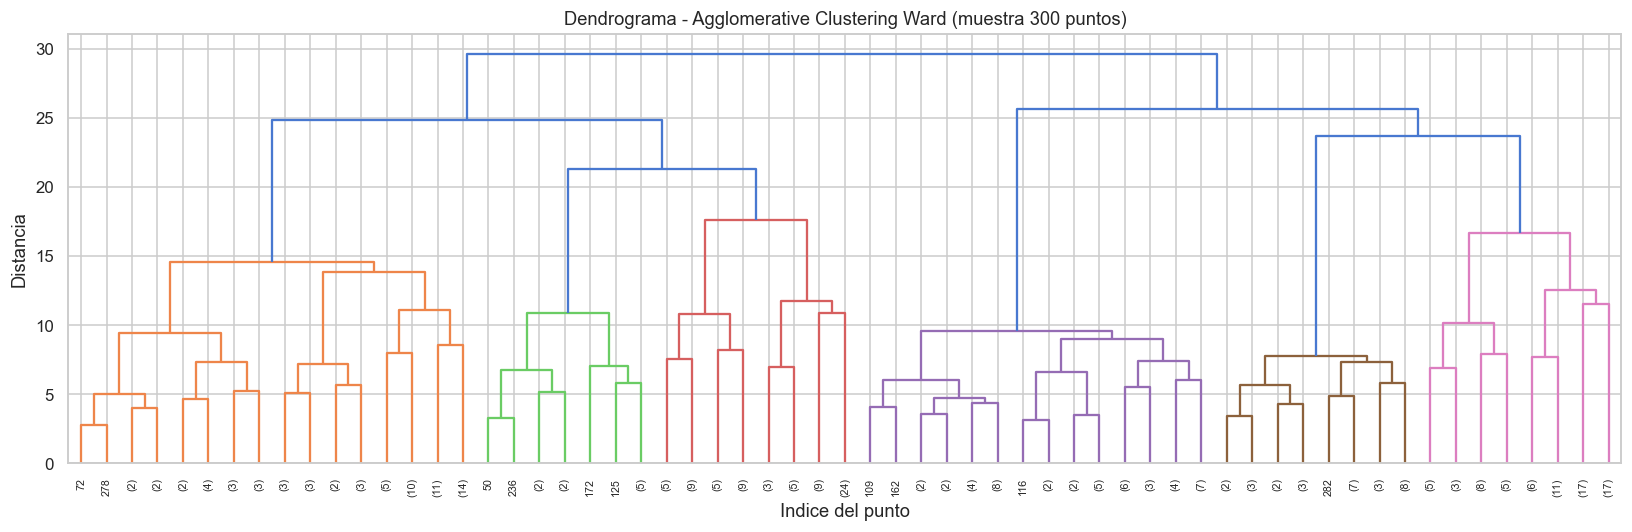

In [31]:
rng        = np.random.default_rng(42)
sample_idx = rng.choice(len(X_prep), 300, replace=False)
Z          = scipy_linkage(X_prep[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(15, 5))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=Z[-5, 2])
ax.set_title('Dendrograma - Agglomerative Clustering Ward (muestra 300 puntos)')
ax.set_xlabel('Indice del punto'); ax.set_ylabel('Distancia')
plt.tight_layout(); plt.show()

linkage=ward    , k=2 | silhouette=0.1184


linkage=ward    , k=3 | silhouette=0.1095


linkage=ward    , k=4 | silhouette=0.0683


linkage=ward    , k=5 | silhouette=0.0798


linkage=ward    , k=6 | silhouette=0.0772


...

linkage=average , k=4 | silhouette=0.0953


linkage=average , k=5 | silhouette=0.0469


linkage=average , k=6 | silhouette=0.0507


linkage=average , k=7 | silhouette=0.0454


linkage=average , k=8 | silhouette=0.0101


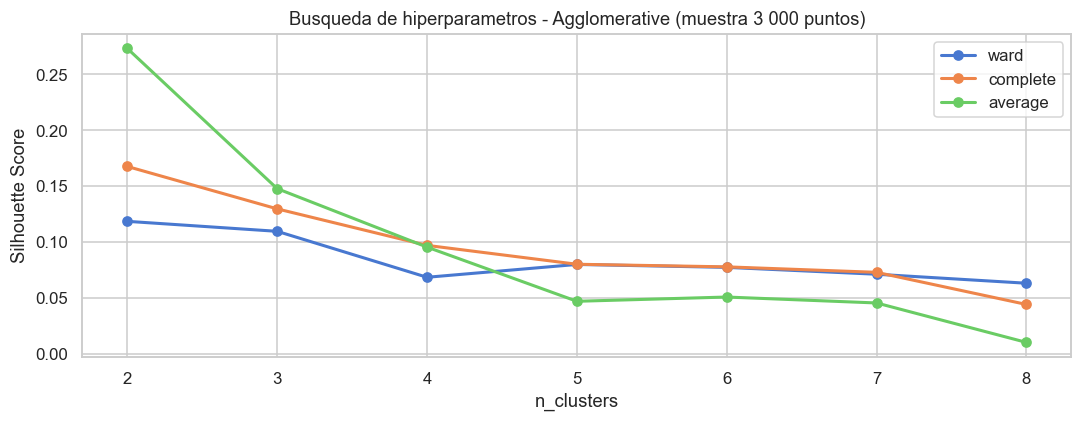

Mejor configuracion (ward): k=2 | silhouette=0.1184
Nota: average obtuvo mejor silueta en la muestra pero produce clusters
degenerados en el dataset completo (chaining) -> descartado.


In [32]:
rng2    = np.random.default_rng(0)
idx_3k  = rng2.choice(len(X_prep), 3000, replace=False)
X_3k    = X_prep[idx_3k]

k_range_ag  = range(2, 9)
linkages_ag = ["ward", "complete", "average"]
agg_scores  = {lnk: [] for lnk in linkages_ag}

for lnk in linkages_ag:
    for k in k_range_ag:
        lbs = AgglomerativeClustering(n_clusters=k, linkage=lnk).fit_predict(X_3k)
        sil = silhouette_score(X_3k, lbs, random_state=42)
        agg_scores[lnk].append(sil)
        print(f"linkage={lnk:8s}, k={k} | silhouette={sil:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
for lnk, scores in agg_scores.items():
    ax.plot(list(k_range_ag), scores, "o-", label=lnk, linewidth=2)
ax.set_xlabel("n_clusters"); ax.set_ylabel("Silhouette Score")
ax.set_title("Busqueda de hiperparametros - Agglomerative (muestra 3 000 puntos)")
ax.set_xticks(list(k_range_ag)); ax.legend()
plt.tight_layout(); plt.show()

# average/complete producen chaining en datos completos (cluster gigante + singletons).
# Se usa ward, robusto y eficiente en datasets grandes.
best_lnk  = "ward"
best_k_ag = list(k_range_ag)[int(np.argmax(agg_scores["ward"]))]
ward_best_sil = max(agg_scores["ward"])
print("Mejor configuracion (ward): k=" + str(best_k_ag) + " | silhouette=" + str(round(ward_best_sil, 4)))
print("Nota: average obtuvo mejor silueta en la muestra pero produce clusters")
print("degenerados en el dataset completo (chaining) -> descartado.")

In [55]:
from sklearn.metrics import calinski_harabasz_score

pipeline_agglo = Pipeline([
    ('prep',  make_preprocessor()),
    ('agglo', AgglomerativeClustering(n_clusters=best_k_ag, linkage=best_lnk))
])

labels_ag = pipeline_agglo.fit_predict(df_model)

vals_ag, cnts_ag = np.unique(labels_ag, return_counts=True)
print(f"best_k_ag={best_k_ag}, best_lnk={best_lnk}")
print("Distribucion de clusters:")
for v, c in zip(vals_ag, cnts_ag):
    print(f"  Cluster {v}: {c:>5} pasajeros ({c/len(labels_ag)*100:.1f}%)")

n_unique_ag = len(vals_ag)
if n_unique_ag < 2:
    raise ValueError(f"Solo {n_unique_ag} cluster(s). Verifica best_k_ag >= 2 (actual: {best_k_ag}).")

# silhouette sin sample_size para evitar fallas con clusters desbalanceados
sil_ag = silhouette_score(X_prep, labels_ag)
ch_ag  = calinski_harabasz_score(X_prep, labels_ag)

print(pipeline_agglo)
print(f'\nSilhouette Score       (k={best_k_ag}, linkage={best_lnk}): {sil_ag:.4f}')
print(f'Calinski-Harabasz Score (k={best_k_ag}, linkage={best_lnk}): {ch_ag:.2f}')

best_k_ag=2, best_lnk=average
Distribucion de clusters:
  Cluster 0:  9999 pasajeros (100.0%)
  Cluster 1:     1 pasajeros (0.0%)
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                        

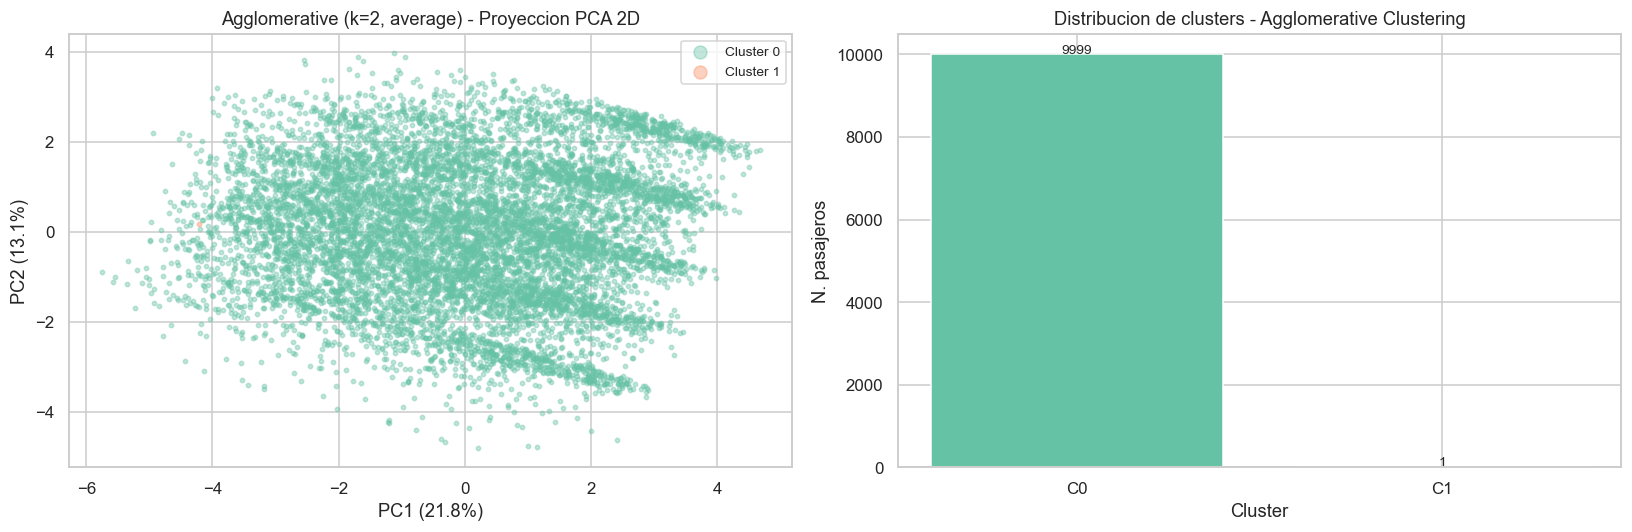

In [56]:
palette_ag = sns.color_palette('Set2', best_k_ag)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i in range(best_k_ag):
    m = labels_ag == i
    ax1.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.4,
                color=palette_ag[i], label=f'Cluster {i}')
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'Agglomerative (k={best_k_ag}, {best_lnk}) - Proyeccion PCA 2D')
ax1.legend(markerscale=3, fontsize=9)

ax2.bar([f'C{v}' for v in vals_ag], cnts_ag, color=palette_ag)
ax2.set_xlabel('Cluster'); ax2.set_ylabel('N. pasajeros')
ax2.set_title('Distribucion de clusters - Agglomerative Clustering')
for i, (v, c) in enumerate(zip(vals_ag, cnts_ag)):
    ax2.text(i, c + 30, str(c), ha='center', fontsize=9)

plt.tight_layout(); plt.show()